# Performance Attribution Analysis
This notebook generates attribution analysis for the HMM-Hurst-Momentum strategy.

**Three attribution dimensions:**
1. **Regime Attribution** — P&L decomposed by HMM state (which regime drove returns?)
2. **Signal Attribution** — P&L decomposed by signal type (trend-following vs mean-reversion)
3. **Sector Attribution (Brinson)** — Allocation vs Selection vs Interaction effects

Outputs saved to `backtest_result/` for inclusion in the LaTeX report.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

# Ensure we can import from the main/ directory
MAIN_DIR = os.path.dirname(os.path.abspath('__file__'))  # main/
if MAIN_DIR not in sys.path:
    sys.path.insert(0, MAIN_DIR)

import config
from data_loader import load_all_data, build_cap_weighted_market_index
from hmm_strategy import process_universe, calculate_mcap_weighted_returns

OUTPUT_DIR = 'backtest_result'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports OK')

Imports OK


## 1. Load Data & Generate Signals

In [2]:
# Load universe data
data = load_all_data(config.DATA_DIR)
df_prices = data['adjusted']
df_mcap   = data['mktcap']

# Align to start date
GLOBAL_START = pd.Timestamp(year=config.START_YEAR, month=1, day=1)
df_prices = df_prices[df_prices.index >= GLOBAL_START]
df_mcap   = df_mcap[df_mcap.index >= GLOBAL_START]

print(f'Prices shape: {df_prices.shape}')
print(f'Date range:   {df_prices.index[0].date()} -> {df_prices.index[-1].date()}')

Prices shape: (4859, 915)
Date range:   2006-01-04 -> 2025-12-31


In [3]:
# Generate signals using the main pipeline parameters
HURST_WINDOW = config.HURST_WINDOWS[0]  # 200
MOMENTUM_PERIOD = config.MOMENTUM_PERIODS[0]  # 21
tickers_csv = os.path.join(config.DATA_DIR, 'tickers.csv')

strat_ret, bh_ret, signal_df, bic_all, var_df = process_universe(
    df_prices,
    n_states=config.N_STATES,
    tickers_csv_path=tickers_csv,
    hurst_window=HURST_WINDOW,
    momentum_periods=MOMENTUM_PERIOD,
    hurst_upper=config.HURST_UPPER,
    hurst_lower=config.HURST_LOWER,
    holding_days=config.HOLDING_DAYS
)

print(f'Signal matrix:  {signal_df.shape}')
print(f'Strategy returns: {strat_ret.shape}')

Processing assets for states=3, H=200, M=21, U=0.6, L=0.4, HD=10...
  Dispatching 915 assets to CPU worker pool...


Aggregating Results:  37%|█████████████████████▎                                   | 342/915 [00:00<00:00, 3419.11it/s]

Skipping 000406 due to insufficient data.
Skipping 000618 due to insufficient data.
Skipping 000763 due to insufficient data.
Skipping 000817 due to insufficient data.
Skipping 000866 due to insufficient data.
Skipping 000956 due to insufficient data.


Aggregating Results: 100%|█████████████████████████████████████████████████████████| 915/915 [00:00<00:00, 1535.86it/s]

Skipping 600002 due to insufficient data.


Signal matrix:  (4859, 908)
Strategy returns: (4859, 908)


In [4]:
# Build MCap-weighted portfolio returns
portfolio_df = calculate_mcap_weighted_returns(strat_ret, bh_ret, df_mcap)

portfolio_df['Strat_Simple'] = np.exp(portfolio_df['Strategy_Return']) - 1
portfolio_df['BH_Simple']    = np.exp(portfolio_df['Log_Return']) - 1
portfolio_df['Strat_Cum']    = (1 + portfolio_df['Strat_Simple']).cumprod()
portfolio_df['BH_Cum']       = (1 + portfolio_df['BH_Simple']).cumprod()

print(f'Portfolio date range: {portfolio_df.index[0].date()} -> {portfolio_df.index[-1].date()}')
print(f'Strategy cumulative:  {portfolio_df["Strat_Cum"].iloc[-1]:.4f}')
print(f'Buy & Hold cumulative: {portfolio_df["BH_Cum"].iloc[-1]:.4f}')

Calculating Market Cap weighted portfolio returns...
Portfolio date range: 2006-11-20 -> 2025-12-31
Strategy cumulative:  1.0554
Buy & Hold cumulative: 0.8418


## 2. Reconstruct Regime Series
We need the per-day HMM regime classification at the portfolio level.
The signal_df encodes signals as {-1, 0, 1}. We reconstruct regimes by
re-running a lightweight HMM on the market-cap-weighted index.

In [5]:
from hmmlearn.hmm import GaussianHMM

# Build MCW index returns for regime detection
mcw_out, mcw_weights, asset_ret = build_cap_weighted_market_index(df_prices, df_mcap)
mcw_returns = mcw_out['market_cap_weighted_return'].dropna()

# Fit a 3-state HMM on the full sample (consistent with paper)
X = mcw_returns.values.reshape(-1, 1)
hmm_model = GaussianHMM(n_components=config.N_STATES, covariance_type='full',
                         n_iter=200, random_state=42)
hmm_model.fit(X)
hidden_states = hmm_model.predict(X)

# Sort states by variance (State 0 = lowest vol, State N-1 = highest vol)
state_vars = [hmm_model.covars_[i][0, 0] for i in range(config.N_STATES)]
sorted_map = {old: new for new, old in enumerate(np.argsort(state_vars))}
regime_series = pd.Series([sorted_map[s] for s in hidden_states],
                          index=mcw_returns.index, name='Regime')

# Label mapping
REGIME_LABELS = {0: 'Low Vol (Risk-On)', 1: 'Medium Vol', 2: 'High Vol (Panic)'}
if config.N_STATES == 2:
    REGIME_LABELS = {0: 'Low Vol (Risk-On)', 1: 'High Vol (Panic)'}

print('Regime distribution:')
print(regime_series.map(REGIME_LABELS).value_counts().sort_index())

Regime distribution:
Regime
High Vol (Panic)     1605
Low Vol (Risk-On)    2775
Medium Vol            478
Name: count, dtype: int64


## 3. Regime Attribution
Decompose total strategy return by the HMM regime that was active on each day.

In [6]:
# Align regime to portfolio dates
analysis = portfolio_df[['Strat_Simple', 'BH_Simple']].copy()
analysis['Regime'] = regime_series.reindex(analysis.index).ffill().fillna(0).astype(int)
analysis['Active_Return'] = analysis['Strat_Simple'] - analysis['BH_Simple']

# Per-regime statistics
regime_stats = []
for r in sorted(analysis['Regime'].unique()):
    mask = analysis['Regime'] == r
    sub = analysis.loc[mask]
    n_days = len(sub)
    strat_cum = (1 + sub['Strat_Simple']).prod() - 1
    bh_cum    = (1 + sub['BH_Simple']).prod() - 1
    active_cum = strat_cum - bh_cum
    avg_daily_active = sub['Active_Return'].mean()
    hit_rate = (sub['Active_Return'] > 0).mean()
    regime_stats.append({
        'Regime': REGIME_LABELS.get(r, f'State {r}'),
        'Days': n_days,
        'Pct of Sample': f'{100*n_days/len(analysis):.1f}%',
        'Strategy Cum Ret': f'{strat_cum:.4f}',
        'Benchmark Cum Ret': f'{bh_cum:.4f}',
        'Active Cum Ret': f'{active_cum:.4f}',
        'Avg Daily Alpha (bps)': f'{avg_daily_active*10000:.2f}',
        'Hit Rate': f'{hit_rate:.1%}'
    })

regime_attr_df = pd.DataFrame(regime_stats)
print('\n=== REGIME ATTRIBUTION ===')
display(regime_attr_df)


=== REGIME ATTRIBUTION ===


,Regime,Days,Pct of Sample,Strategy Cum Ret,Benchmark Cum Ret,Active Cum Ret,Avg Daily Alpha (bps),Hit Rate
0,Low Vol (Risk-On),2653,57.1%,0.0147,0.0494,-0.0347,-0.20,52.9%
1,Medium Vol,440,9.5%,0.0133,0.2129,-0.1996,-4.25,47.5%
2,High Vol (Panic),1555,33.5%,0.0264,-0.3387,0.3651,2.42,57.0%


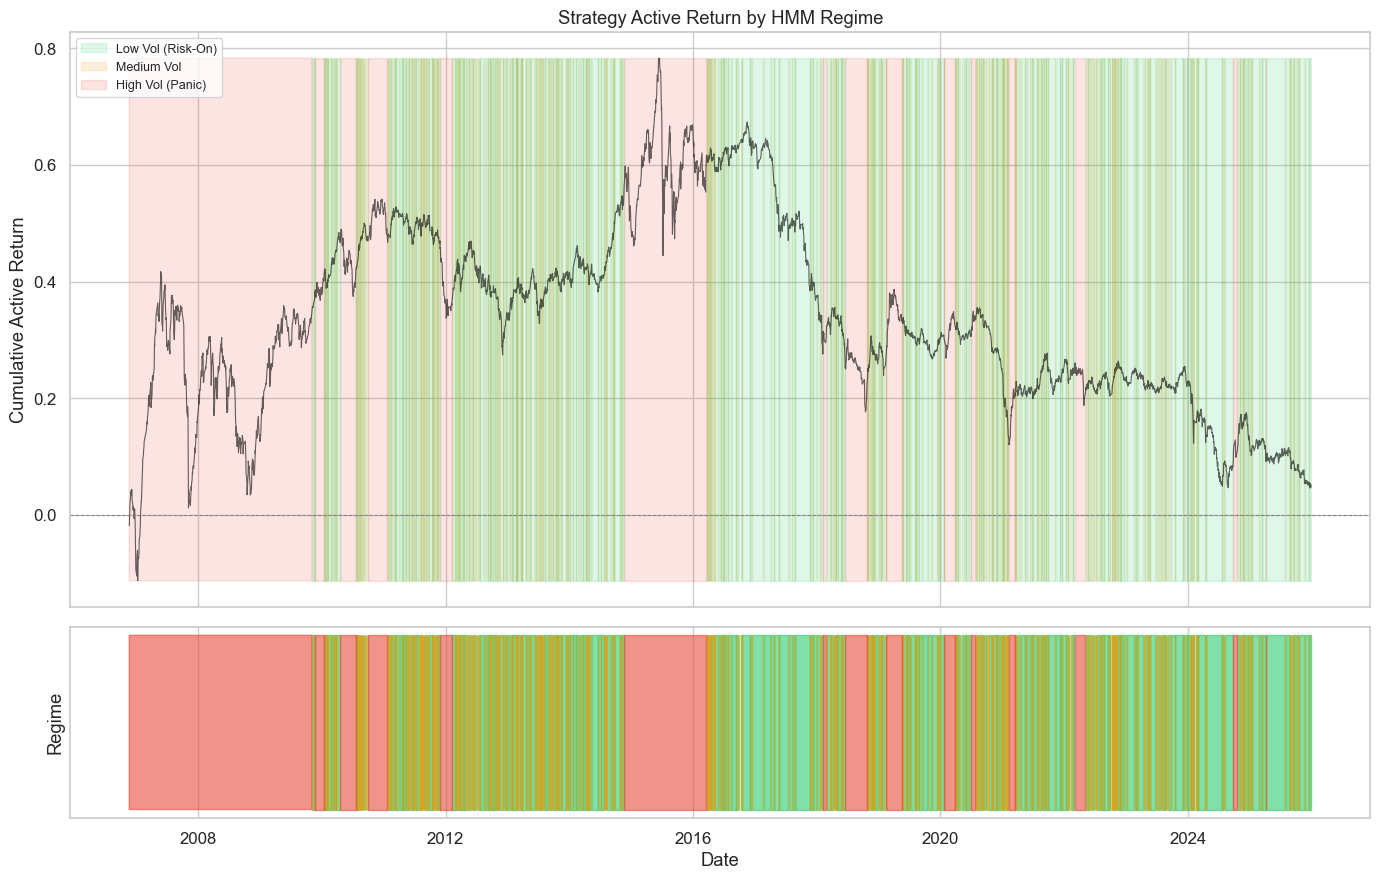

In [7]:
# Plot: Cumulative active return coloured by regime
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Top panel: cumulative active return
cum_active = (1 + analysis['Active_Return']).cumprod() - 1
colors_map = {0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'}
regime_colors = analysis['Regime'].map(colors_map)

ax = axes[0]
ax.plot(cum_active.index, cum_active.values, color='black', linewidth=0.8, alpha=0.6)
for r in sorted(analysis['Regime'].unique()):
    mask = analysis['Regime'] == r
    ax.fill_between(cum_active.index, cum_active.min(), cum_active.max(),
                    where=mask, alpha=0.15, color=colors_map[r],
                    label=REGIME_LABELS.get(r, f'State {r}'))
ax.set_ylabel('Cumulative Active Return')
ax.set_title('Strategy Active Return by HMM Regime')
ax.legend(loc='upper left', fontsize=9)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

# Bottom panel: regime timeline
ax2 = axes[1]
for r in sorted(analysis['Regime'].unique()):
    mask = analysis['Regime'] == r
    ax2.fill_between(analysis.index, 0, 1, where=mask, alpha=0.6,
                     color=colors_map[r], label=REGIME_LABELS.get(r, f'State {r}'))
ax2.set_ylabel('Regime')
ax2.set_yticks([])
ax2.set_xlabel('Date')

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'regime_attribution.png'), dpi=200, bbox_inches='tight')
plt.show()
#print(f'Saved to {OUTPUT_DIR}/regime_attribution.png')

## 4. Signal-Type Attribution
Decompose returns by signal type: Long (+1), Short (-1), Cash (0).

In [8]:
# Aggregate signal across universe: net signal direction per day
# Positive net signal = mostly long; Negative = mostly short; ~0 = mixed/cash
daily_net_signal = signal_df.mean(axis=1)  # average signal across tickers

# Classify each day
def classify_signal(s):
    if s > 0.1:
        return 'Net Long'
    elif s < -0.1:
        return 'Net Short'
    else:
        return 'Cash / Neutral'

signal_class = daily_net_signal.map(classify_signal)
signal_class.name = 'Signal_Type'

# Merge with portfolio returns
sig_analysis = portfolio_df[['Strat_Simple', 'BH_Simple']].copy()
sig_analysis['Signal_Type'] = signal_class.reindex(sig_analysis.index).fillna('Cash / Neutral')
sig_analysis['Active_Return'] = sig_analysis['Strat_Simple'] - sig_analysis['BH_Simple']

# Per-signal stats
signal_stats = []
for stype in ['Net Long', 'Cash / Neutral', 'Net Short']:
    sub = sig_analysis[sig_analysis['Signal_Type'] == stype]
    if len(sub) == 0:
        continue
    n_days = len(sub)
    total_active = sub['Active_Return'].sum()
    avg_daily = sub['Active_Return'].mean()
    hit = (sub['Active_Return'] > 0).mean()
    signal_stats.append({
        'Signal Type': stype,
        'Days': n_days,
        'Pct of Sample': f'{100*n_days/len(sig_analysis):.1f}%',
        'Cum Active Ret (sum)': f'{total_active:.4f}',
        'Avg Daily Alpha (bps)': f'{avg_daily*10000:.2f}',
        'Hit Rate': f'{hit:.1%}'
    })

signal_attr_df = pd.DataFrame(signal_stats)
print('\n=== SIGNAL-TYPE ATTRIBUTION ===')
display(signal_attr_df)


=== SIGNAL-TYPE ATTRIBUTION ===


,Signal Type,Days,Pct of Sample,Cum Active Ret (sum),Avg Daily Alpha (bps),Hit Rate
0,Net Long,69,1.5%,0.0281,4.08,58.0%
1,Cash / Neutral,4579,98.5%,0.1083,0.24,53.7%


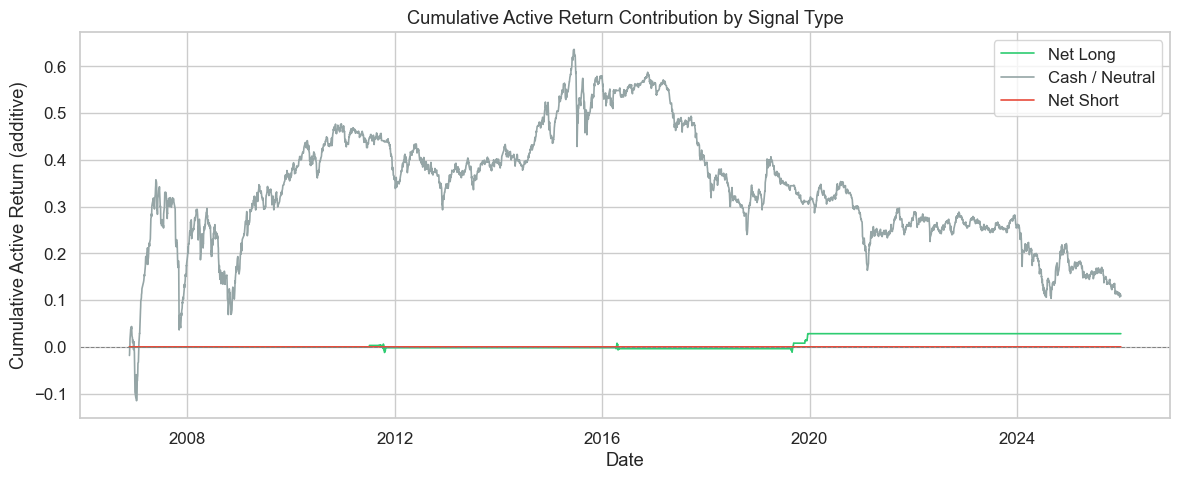

In [11]:
# Plot: Active return contribution by signal type
fig, ax = plt.subplots(figsize=(12, 5))

sig_colors = {'Net Long': '#2ecc71', 'Cash / Neutral': '#95a5a6', 'Net Short': '#e74c3c'}

for stype in ['Net Long', 'Cash / Neutral', 'Net Short']:
    mask = sig_analysis['Signal_Type'] == stype
    contrib = sig_analysis['Active_Return'].where(mask, 0).cumsum()
    ax.plot(contrib.index, contrib.values, label=stype,
            color=sig_colors.get(stype, 'gray'), linewidth=1.2)

ax.set_title('Cumulative Active Return Contribution by Signal Type')
ax.set_ylabel('Cumulative Active Return (additive)')
ax.set_xlabel('Date')
ax.legend()
ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'signal_attribution.png'), dpi=200, bbox_inches='tight')
plt.show()
#print(f'Saved to {OUTPUT_DIR}/signal_attribution.png')

## 5. Sector Attribution (Brinson-Hood-Beebower)
Decompose the active return into Allocation, Selection, and Interaction effects by GICS sector.

In [12]:
# Load GICS sector mapping
GICS_SECTORS = {
    '10': 'Energy', '15': 'Materials', '20': 'Industrials',
    '25': 'Consumer Disc.', '30': 'Consumer Staples', '35': 'Health Care',
    '40': 'Financials', '45': 'Info Tech', '50': 'Comm Services',
    '55': 'Utilities', '60': 'Real Estate'
}

tickers_map = pd.read_csv(os.path.join(config.DATA_DIR, 'tickers.csv'),
                          header=None, names=['ticker', 'gics_code'])
tickers_map['ticker'] = tickers_map['ticker'].astype(str).str.strip()
tickers_map['sector_code'] = tickers_map['gics_code'].astype(str).str[:2]
tickers_map['sector'] = tickers_map['sector_code'].map(GICS_SECTORS).fillna('Other')
ticker_to_sector = tickers_map.set_index('ticker')['sector'].to_dict()

print(f'Mapped {len(ticker_to_sector)} tickers to sectors')
print(pd.Series(ticker_to_sector).value_counts())

Mapped 915 tickers to sectors
Industrials         184
Materials           141
Info Tech           128
Financials           87
Health Care          70
Consumer Disc.       66
Real Estate          50
Consumer Staples     50
Utilities            42
Comm Services        41
Energy               37
Other                19
Name: count, dtype: int64


In [13]:
# Build benchmark weights (MCap-weighted, full universe)
bench_weights = df_mcap.div(df_mcap.sum(axis=1), axis=0).fillna(0)

# Build strategy weights: MCap-weighted but only on active signals
active_mask = signal_df.reindex(index=df_mcap.index, columns=df_mcap.columns).fillna(0)
active_mcap = df_mcap.where(active_mask != 0)
strat_weights = active_mcap.div(active_mcap.sum(axis=1), axis=0).fillna(0)

# Compute stock-level simple returns
stock_returns = df_prices.pct_change()

# Map columns to sectors
col_sectors = pd.Series({c: ticker_to_sector.get(str(c).strip(), 'Other')
                         for c in df_prices.columns})
sectors = sorted(col_sectors.unique())

print(f'Sectors in universe: {sectors}')

Sectors in universe: ['Comm Services', 'Consumer Disc.', 'Consumer Staples', 'Energy', 'Financials', 'Health Care', 'Industrials', 'Info Tech', 'Materials', 'Other', 'Real Estate', 'Utilities']


In [14]:
# Aggregate to sector level: weights and returns
def aggregate_to_sectors(weights_df, returns_df, col_sectors, sectors):
    """Compute sector-level weights and weighted returns."""
    sec_weights = pd.DataFrame(0.0, index=weights_df.index, columns=sectors)
    sec_returns = pd.DataFrame(0.0, index=returns_df.index, columns=sectors)
    
    for sec in sectors:
        ticks = col_sectors[col_sectors == sec].index.tolist()
        ticks = [t for t in ticks if t in weights_df.columns]
        if not ticks:
            continue
        sec_weights[sec] = weights_df[ticks].sum(axis=1)
        # Weighted-average return within sector
        intra_w = weights_df[ticks].div(weights_df[ticks].sum(axis=1), axis=0).fillna(0)
        sec_returns[sec] = (returns_df[ticks] * intra_w).sum(axis=1)
    return sec_weights, sec_returns

bench_sec_w, bench_sec_r = aggregate_to_sectors(bench_weights, stock_returns, col_sectors, sectors)
strat_sec_w, strat_sec_r = aggregate_to_sectors(strat_weights, stock_returns, col_sectors, sectors)

print('Sector aggregation complete.')

Sector aggregation complete.


In [15]:
# BHB Attribution using period-average weights and cumulative returns
n_years = len(bench_sec_r) / 252

# Average weights
wp = strat_sec_w.mean()  ; wp = wp / wp.sum()  # portfolio
wb = bench_sec_w.mean()  ; wb = wb / wb.sum()  # benchmark

# Annualised sector returns
rp = (1 + strat_sec_r).prod() ** (1/n_years) - 1   # portfolio
rb = (1 + bench_sec_r).prod() ** (1/n_years) - 1   # benchmark

# BHB decomposition
allocation  = (wp - wb) * rb
selection   = wb * (rp - rb)
interaction = (wp - wb) * (rp - rb)
total       = allocation + selection + interaction

bhb_df = pd.DataFrame({
    'Port Weight': wp,
    'Bench Weight': wb,
    'Weight Diff': wp - wb,
    'Port Ann Ret': rp,
    'Bench Ann Ret': rb,
    'Allocation': allocation,
    'Selection': selection,
    'Interaction': interaction,
    'Total': total
}).sort_values('Total', ascending=False)

# Summary
print('\n=== BRINSON-HOOD-BEEBOWER ATTRIBUTION (Annualised) ===')
display(bhb_df.style.format({
    'Port Weight': '{:.2%}', 'Bench Weight': '{:.2%}', 'Weight Diff': '{:+.2%}',
    'Port Ann Ret': '{:.2%}', 'Bench Ann Ret': '{:.2%}',
    'Allocation': '{:+.4%}', 'Selection': '{:+.4%}',
    'Interaction': '{:+.4%}', 'Total': '{:+.4%}'
}))

print(f"\nTotal Allocation Effect:  {allocation.sum():+.4%}")
print(f"Total Selection Effect:  {selection.sum():+.4%}")
print(f"Total Interaction Effect: {interaction.sum():+.4%}")
print(f"Total Active Return:     {total.sum():+.4%}")


=== BRINSON-HOOD-BEEBOWER ATTRIBUTION (Annualised) ===


,Port Weight,Bench Weight,Weight Diff,Port Ann Ret,Bench Ann Ret,Allocation,Selection,Interaction,Total
Consumer Disc.,10.63%,5.12%,+5.51%,18.09%,28.67%,+1.5787%,-0.5419%,-0.5828%,+0.4540%
Health Care,6.20%,4.06%,+2.13%,20.22%,30.72%,+0.6557%,-0.4267%,-0.2241%,+0.0049%
Other,0.74%,0.19%,+0.55%,0.23%,9.30%,+0.0508%,-0.0175%,-0.0496%,-0.0163%
Real Estate,5.15%,2.96%,+2.19%,4.34%,17.42%,+0.3816%,-0.3866%,-0.2864%,-0.2914%
Utilities,5.08%,3.41%,+1.66%,3.31%,16.43%,+0.2734%,-0.4476%,-0.2183%,-0.3925%
Materials,12.59%,8.28%,+4.30%,10.13%,23.26%,+1.0013%,-1.0880%,-0.5654%,-0.6521%
Comm Services,1.84%,7.33%,-5.49%,-3.79%,9.22%,-0.5067%,-0.9539%,+0.7148%,-0.7458%
Info Tech,6.94%,6.59%,+0.35%,20.69%,38.39%,+0.1355%,-1.1664%,-0.0625%,-1.0934%
Energy,4.47%,12.46%,-7.99%,6.53%,11.21%,-0.8963%,-0.5837%,+0.3744%,-1.1055%
Consumer Staples,6.12%,5.95%,+0.18%,7.85%,28.81%,+0.0513%,-1.2461%,-0.0373%,-1.2321%



Total Allocation Effect:  +2.7363%
Total Selection Effect:  -12.5732%
Total Interaction Effect: -0.8457%
Total Active Return:     -10.6826%


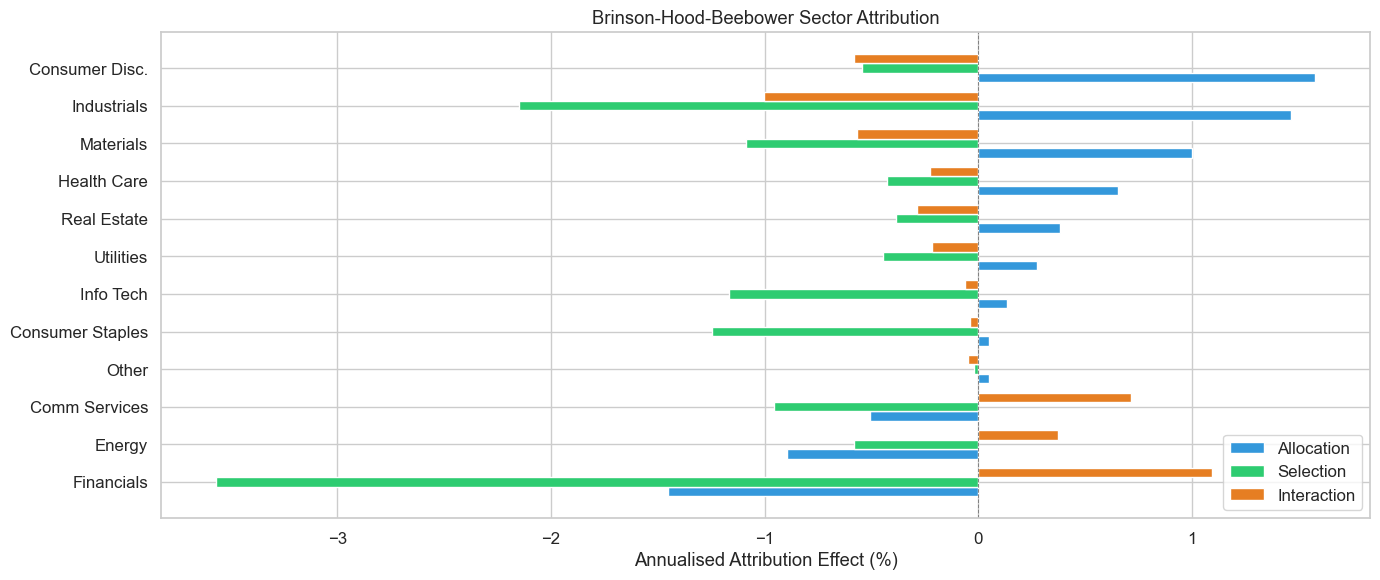

Saved to backtest_result/brinson_sector_attribution.png


In [16]:
# Plot: BHB waterfall by sector
fig, ax = plt.subplots(figsize=(14, 6))

plot_df = bhb_df[['Allocation', 'Selection', 'Interaction']].copy()
plot_df = plot_df.sort_values('Allocation', ascending=True)

x = np.arange(len(plot_df))
width = 0.25

ax.barh(x - width, plot_df['Allocation']*100, width, label='Allocation', color='#3498db')
ax.barh(x,         plot_df['Selection']*100,   width, label='Selection',  color='#2ecc71')
ax.barh(x + width, plot_df['Interaction']*100, width, label='Interaction',color='#e67e22')

ax.set_yticks(x)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel('Annualised Attribution Effect (%)')
ax.set_title('Brinson-Hood-Beebower Sector Attribution')
ax.legend(loc='lower right')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'brinson_sector_attribution.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT_DIR}/brinson_sector_attribution.png')

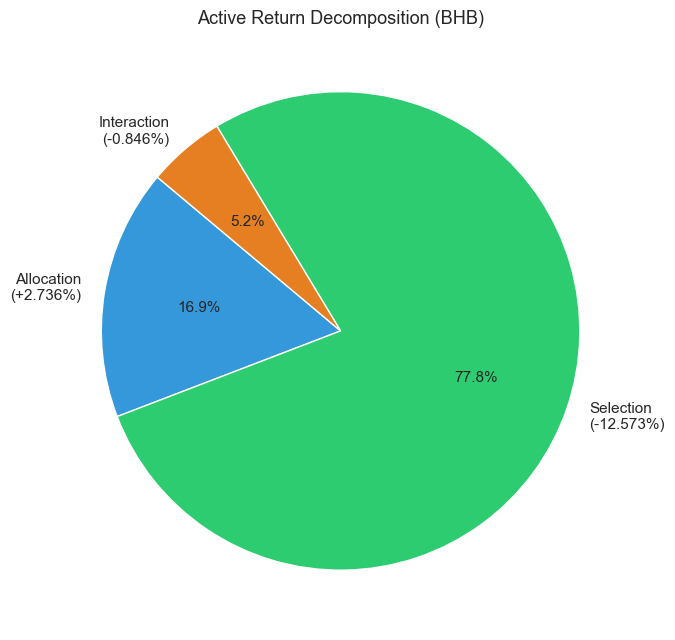

In [17]:
# Plot: Summary pie — contribution breakdown
fig, ax = plt.subplots(figsize=(7, 7))

totals = [abs(allocation.sum()), abs(selection.sum()), abs(interaction.sum())]
labels_pie = [
    f'Allocation\n({allocation.sum():+.3%})',
    f'Selection\n({selection.sum():+.3%})',
    f'Interaction\n({interaction.sum():+.3%})'
]
colors_pie = ['#3498db', '#2ecc71', '#e67e22']

if sum(totals) > 0:
    ax.pie(totals, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
           startangle=140, textprops={'fontsize': 11})
    ax.set_title('Active Return Decomposition (BHB)', fontsize=13)
else:
    ax.text(0.5, 0.5, 'No meaningful active return to decompose',
            ha='center', va='center', fontsize=12)

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'bhb_pie_decomposition.png'), dpi=200, bbox_inches='tight')
plt.show()
#print(f'Saved to {OUTPUT_DIR}/bhb_pie_decomposition.png')

## 6. Combined Regime × Signal Heatmap
Cross-tabulate regime and signal type to show where alpha concentrates.

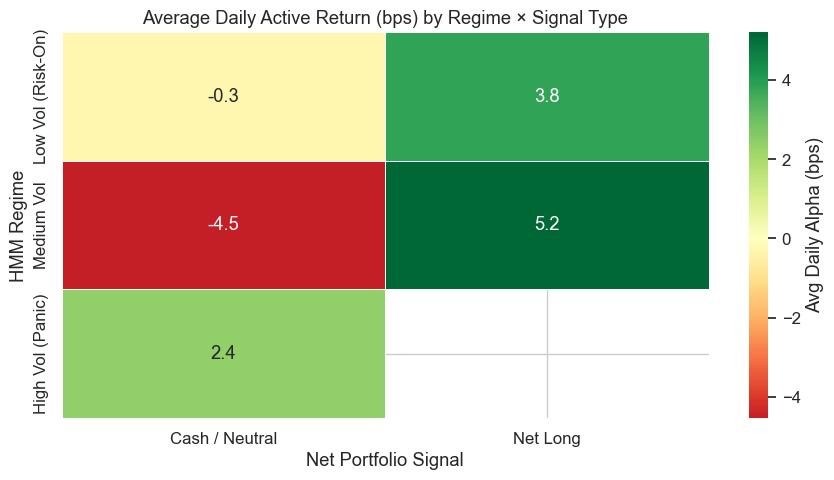

In [18]:
# Merge regime and signal type into one frame
combined = portfolio_df[['Strat_Simple', 'BH_Simple']].copy()
combined['Active'] = combined['Strat_Simple'] - combined['BH_Simple']
combined['Regime'] = regime_series.reindex(combined.index).ffill().fillna(0).astype(int)
combined['Signal_Type'] = signal_class.reindex(combined.index).fillna('Cash / Neutral')

# Pivot: mean daily active return (bps)
heatmap_data = combined.pivot_table(
    values='Active', index='Regime', columns='Signal_Type',
    aggfunc='mean'
) * 10000  # convert to bps

# Relabel regime index
heatmap_data.index = [REGIME_LABELS.get(r, f'State {r}') for r in heatmap_data.index]

# Count matrix
count_data = combined.pivot_table(
    values='Active', index='Regime', columns='Signal_Type',
    aggfunc='count'
)
count_data.index = heatmap_data.index

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Daily Alpha (bps)'})
ax.set_title('Average Daily Active Return (bps) by Regime × Signal Type')
ax.set_ylabel('HMM Regime')
ax.set_xlabel('Net Portfolio Signal')

plt.tight_layout()
#plt.savefig(os.path.join(OUTPUT_DIR, 'regime_signal_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()
#print(f'Saved to {OUTPUT_DIR}/regime_signal_heatmap.png')